# GAN + TapSEGNN  

In [1]:
import random 
import numpy as np 
import torch 
import os 
import sys 
import time 
from torch_geometric.loader import DataLoader 
import torch.nn as nn 
from torch_geometric.data import Dataset 
from datetime import datetime
from typing import Dict 
import copy 

parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, parent_dir)

from src.model.graph_model import NEGATGenerator
from src.dataset.custom_dataset import NodeEdgeTapDatasetV2
from src.training.trainer import trainer 

from utils.gen_utils import load_config, get_device, dataset_splitter, generate_markdown_report
from utils.ppnet_utils import initialize_network
from utils.model_utils import initialize_model, get_eval_results
from utils.load_data_utils import load_sampled_input_data

## Initialise the configuration for GAN and TapSEGNN 

In [2]:
seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

config_tapsegnn = load_config('config.yaml')

device = get_device(config_tapsegnn['device'])

net = initialize_network(net_name=config_tapsegnn['data']['net_name'], 
                         load_std=config_tapsegnn['data']['load_std'])


Network: net_A is selected 

Net net_A has 42 nodes and 42 edges. 



In [3]:
start_data_load = time.perf_counter()
sampled_input_data = load_sampled_input_data(sc_type=config_tapsegnn['data']['scenario_type'], 
                                            net=net, 
                                            num_samples=config_tapsegnn['data']['num_samples'],
                                            noise=config_tapsegnn['data']['noise'],
                                            trafo_ids=config_tapsegnn['data']['trafo_ids'],
                                            scaler=config_tapsegnn['data']['scaler'],
                                            )

end_data_load = time.perf_counter()
print(f"Dataloading took {end_data_load - start_data_load} seconds.\n\n")

# sparsity of the node and edge features 
node_feat_sparsity = np.count_nonzero(sampled_input_data['node_mask']) / sampled_input_data['node_mask'].numpy().size
pflow_edge_sparsity = np.count_nonzero(sampled_input_data['edge_mask'][:,:,0]) / sampled_input_data['edge_mask'][:,:,0].numpy().size

print(f"Sparsity of PV measurements at buses = {node_feat_sparsity:.1f}%")
print(f"Sparsity of P+ measurements at branches = {pflow_edge_sparsity:.1f}")

Selecting all the MV/LV transformers in the network 

Scaling inputs...
Number of V, P measurements 43 out of 84

Number of P_to, Q_to, P_from, Q_from measurements 22 out of 42

Dataloading took 28.719421916999636 seconds.


Sparsity of PV measurements at buses = 0.5%
Sparsity of P+ measurements at branches = 0.5


In [4]:
# dataset with missing measurements
dataset_w_mm = NodeEdgeTapDatasetV2(model_name=config_tapsegnn['model']['name'], 
                               sampled_input_data=sampled_input_data, 
                               missing_measurements=True)

# (train_loader, val_loader, test_loader), _ = dataset_splitter(dataset, 
#                                                               batch_size=config_tapsegnn['loader']['batch_size'])

Dataset for MultiTapSEGNN selected!


 Directed power flows accounted in dataset...


 get_edge_index_lu handling dictionary of tensors...



In [5]:
# load the generator model 
model_G = NEGATGenerator(node_input_features=dataset_w_mm[0][0].x.shape[-1], 
                    list_node_hidden_features=config_tapsegnn['model']['list_node_hidden_features'], # [128,64], 
                    node_out_features=config_tapsegnn['model']['node_out_features'], # 64, 
                    k_hop_node=config_tapsegnn['model']['k_hop_node'], #1, 
                    edge_input_features=dataset_w_mm[0][1].x.shape[-1], 
                    list_edge_hidden_features=config_tapsegnn['model']['list_edge_hidden_features'], #[128,64], 
                    edge_output_features=1, #1, 
                    k_hop_edge=config_tapsegnn['model']['k_hop_edge'], #1, 
                    gat_out_features=config_tapsegnn['model']['gat_out_features'], #32, 
                    gat_head=config_tapsegnn['model']['gat_head'], #2, 
                    device=device)

checkpoint = torch.load(parent_dir + "/results/Best_G.pth")
model_G.load_state_dict(checkpoint)

<All keys matched successfully>

In [7]:
def impute_dataset_with_model_G(model_G: nn.Module, 
                                dataset_w_mm: Dataset, 
                                sampled_input_data: Dict):     
    loader = DataLoader(dataset_w_mm, batch_size=1, shuffle=False)
    cp_sampled_input_data = copy.deepcopy(sampled_input_data)
    cp_sampled_input_data['node_input_feat_mm'] = torch.zeros_like(cp_sampled_input_data['node_input_feat'])
    cp_sampled_input_data['edge_input_feat_mm'] = torch.zeros_like(cp_sampled_input_data['edge_input_feat']) 

    # forward pass of model_G 
    for batch_id, batch in enumerate(loader): 
        with torch.no_grad(): 
            scaled_gen_pv, scaled_gen_p_edge = model_G(batch)
            # REPLACE (lazy implementation) the node and edge input features for TapSEGNN
            cp_sampled_input_data['node_input_feat_mm'][batch_id] = scaled_gen_pv
            cp_sampled_input_data['edge_input_feat_mm'][batch_id,:,0] = scaled_gen_p_edge 
            break
    return cp_sampled_input_data

# dataset with imputed pv and p edge
sampled_input_data_imputed = impute_dataset_with_model_G(model_G=model_G, 
                                                        dataset_w_mm=dataset_w_mm, 
                                                        sampled_input_data=sampled_input_data)

dataset = NodeEdgeTapDatasetV2(model_name=config_tapsegnn['model']['name'], 
                               sampled_input_data=sampled_input_data_imputed)

Dataset for MultiTapSEGNN selected!


 Directed power flows accounted in dataset...


 get_edge_index_lu handling dictionary of tensors...



All transformers have same number of taps, using shared parameter \omega.
Total number of parameters of model MultiTapSEGNN(
  (node_layers): ModuleList(
    (0): TAGConv(2, 64, K=3)
    (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (fc_node): Linear(in_features=64, out_features=32, bias=True)
  (edge_layers): ModuleList(
    (0): ModuleList(
      (0-1): 2 x TAGConv(6, 128, K=1)
    )
  )
  (edge_biases): ParameterList(  (0): Parameter containing: [torch.float32 of size 128])
  (fc_edge): Linear(in_features=128, out_features=64, bias=True)
  (gatconv): GATConv(32, 32, heads=1)
  (mlp_gat): Sequential(
    (0): Linear(in_features=32, out_features=2, bias=True)
  )
  (multi_trafo_mlp_o): ModuleList(
    (0-1): 2 x ModuleList(
      (0): Linear(in_features=2, out_features=16, bias=True)
      (1): Linear(in_features=16, out_features=5, bias=True)
    )
  )
  (multi_trafo_mlp_a): ModuleDict(
    (trafo a - 0): Linear(in_features=4, out_features=1, bias=True)
    (trafo a

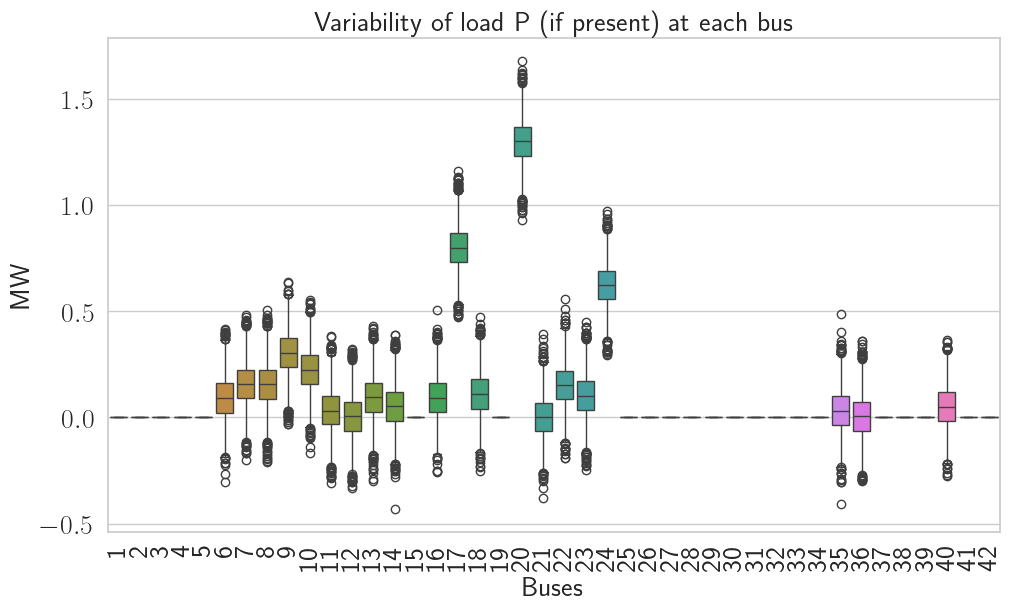

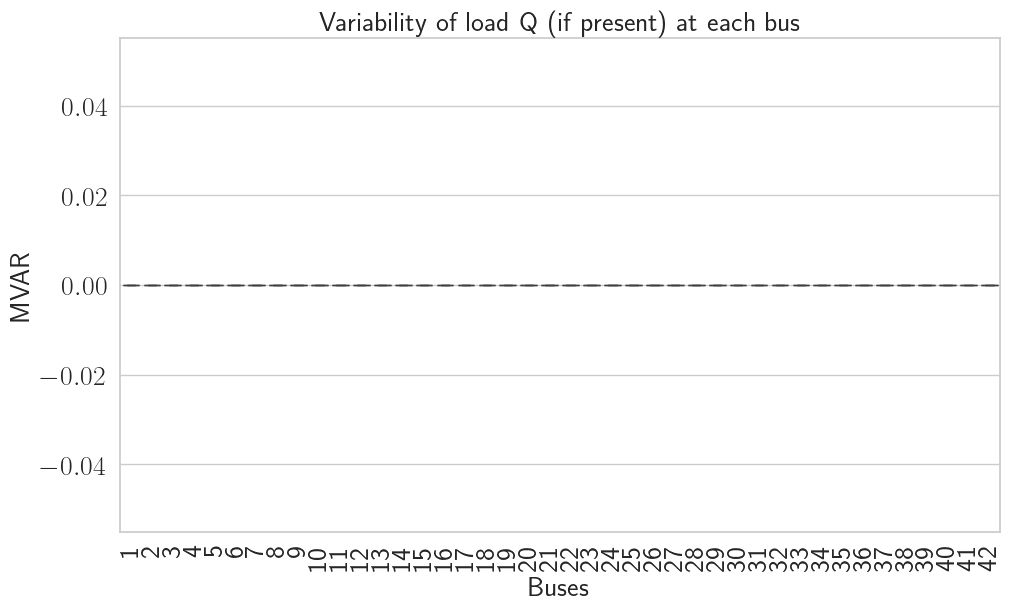

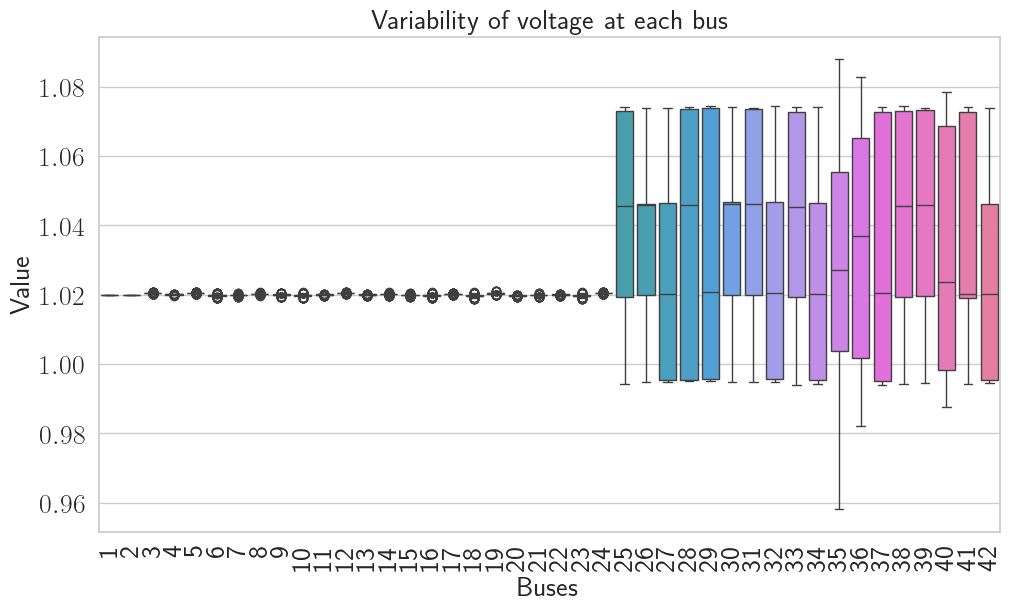

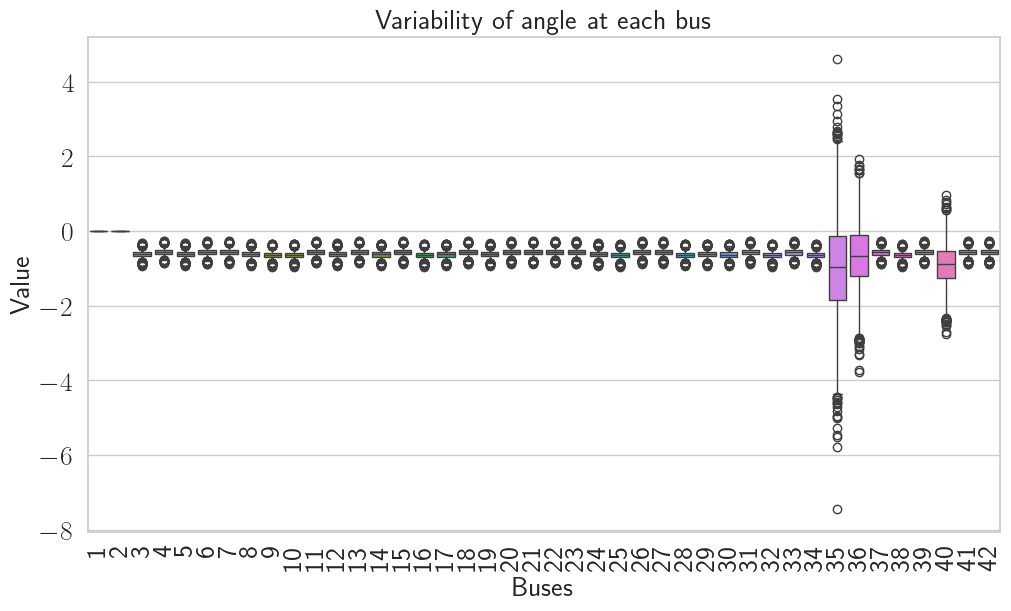

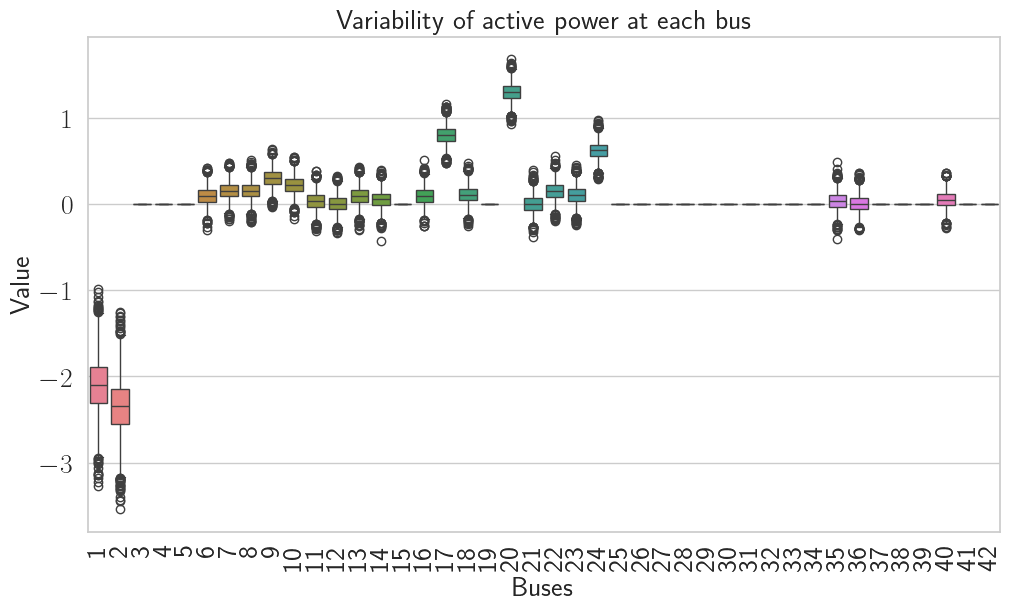

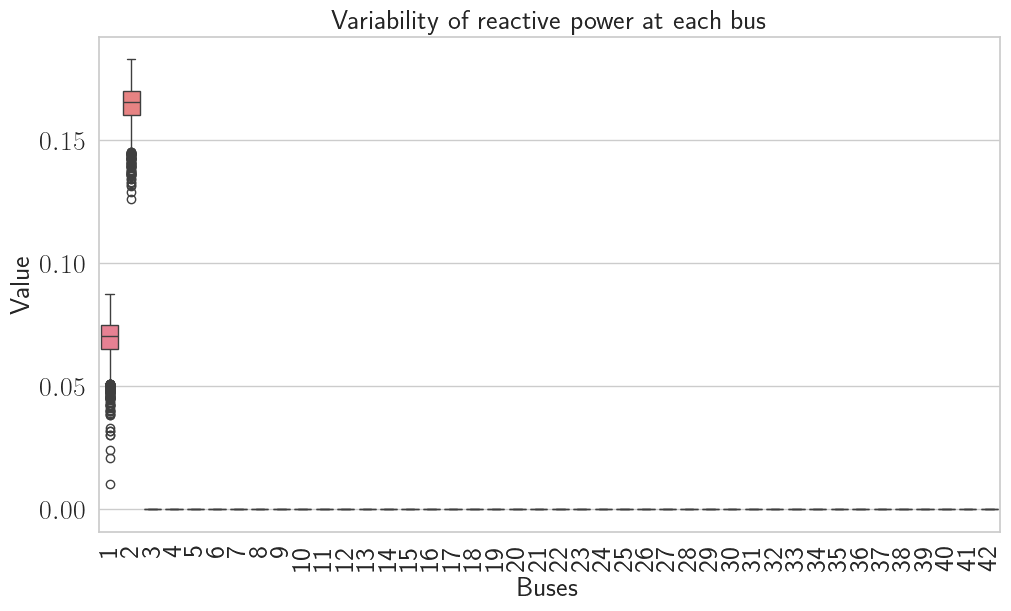

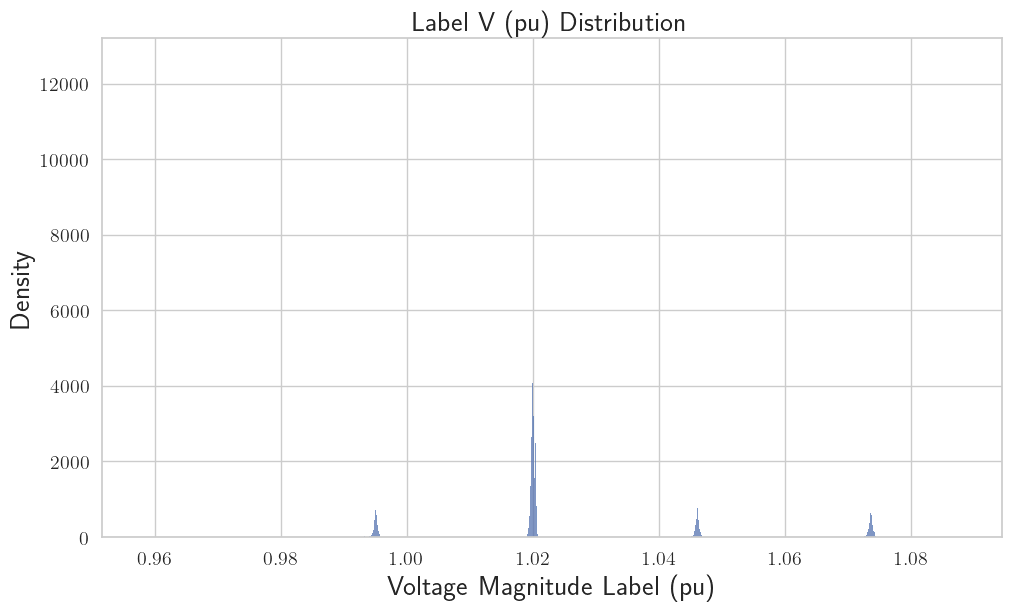

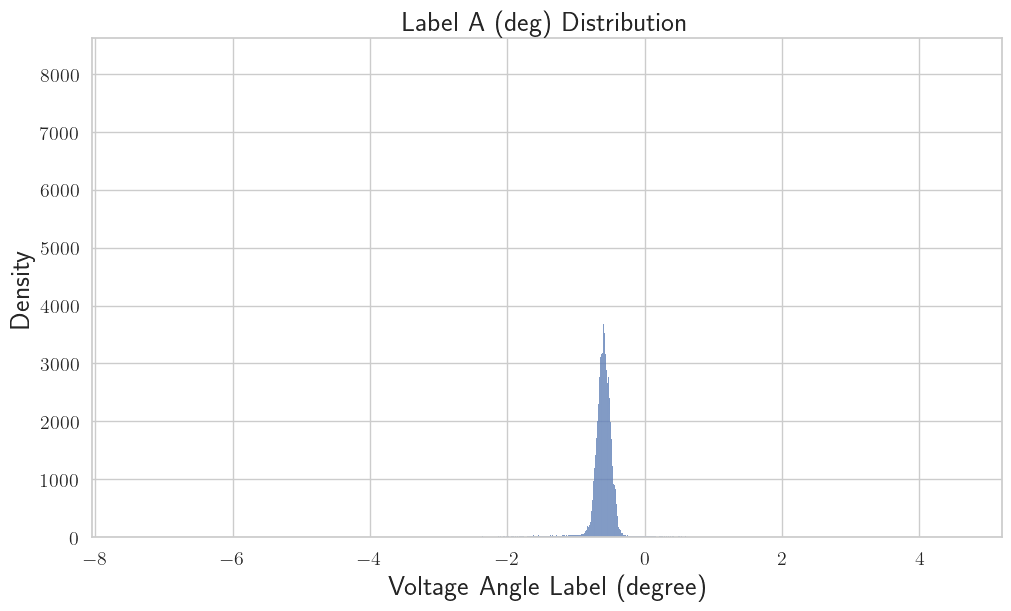

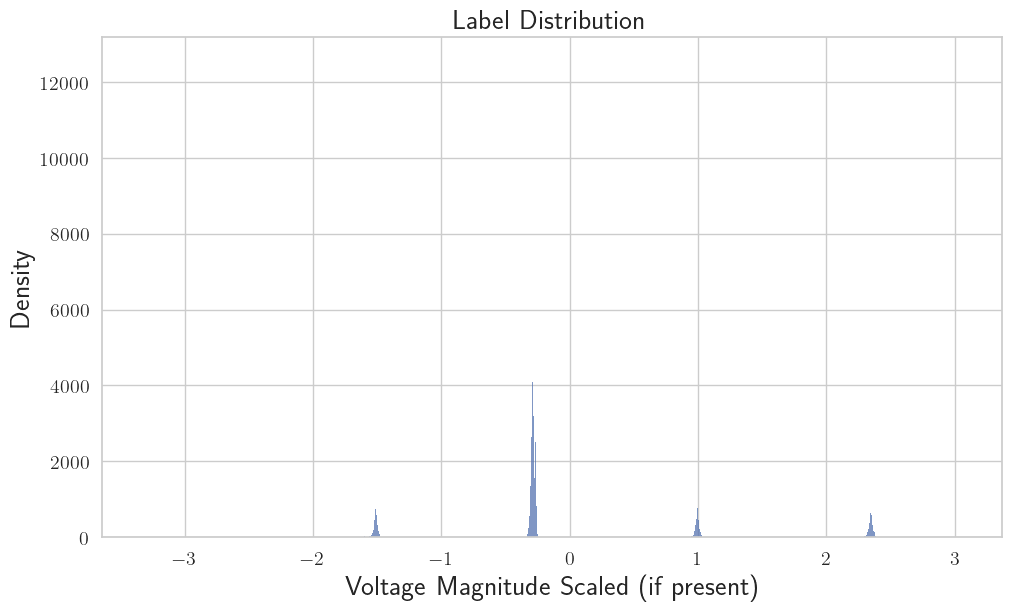

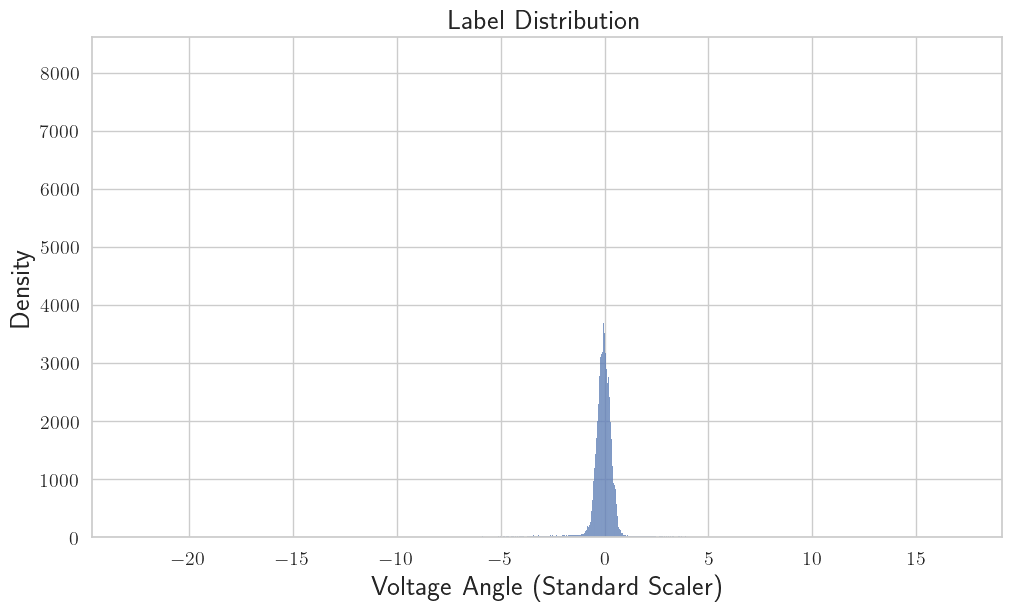

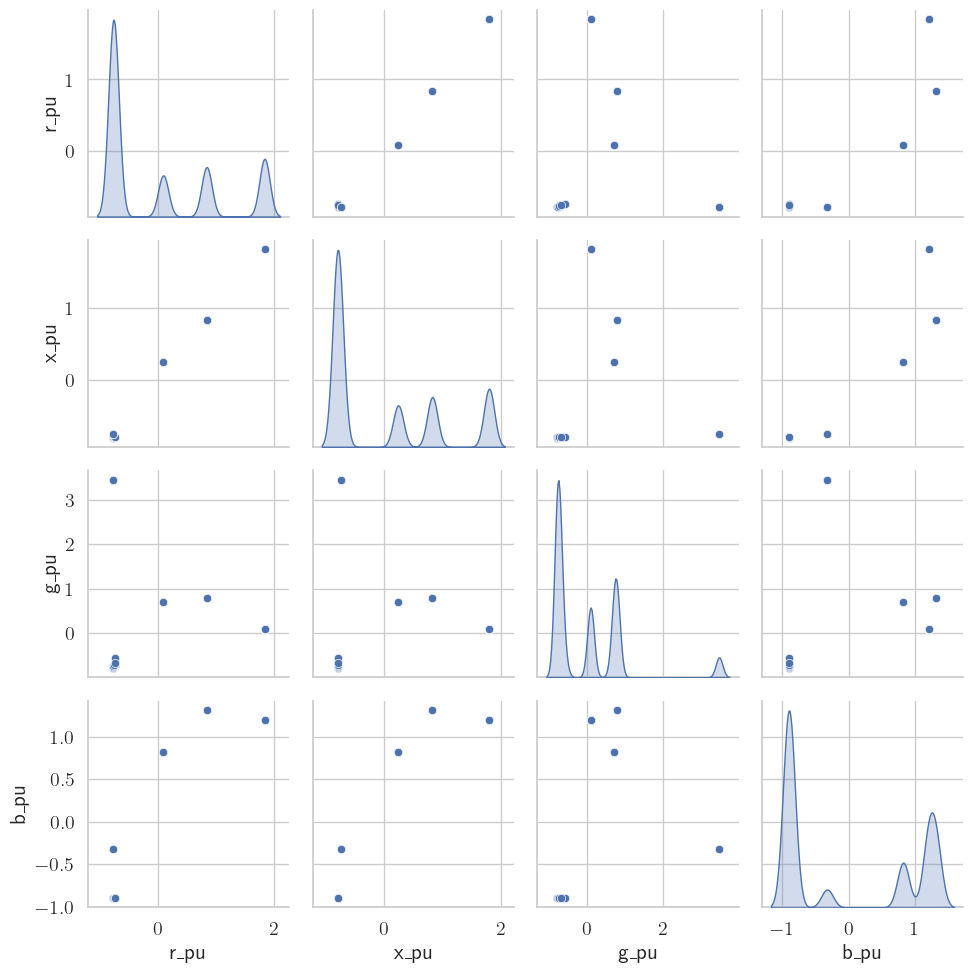

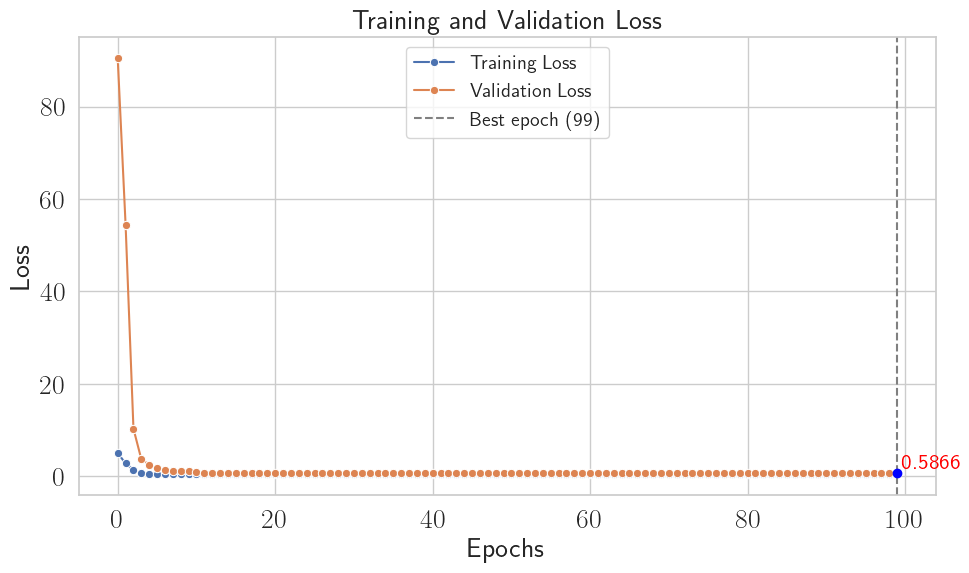

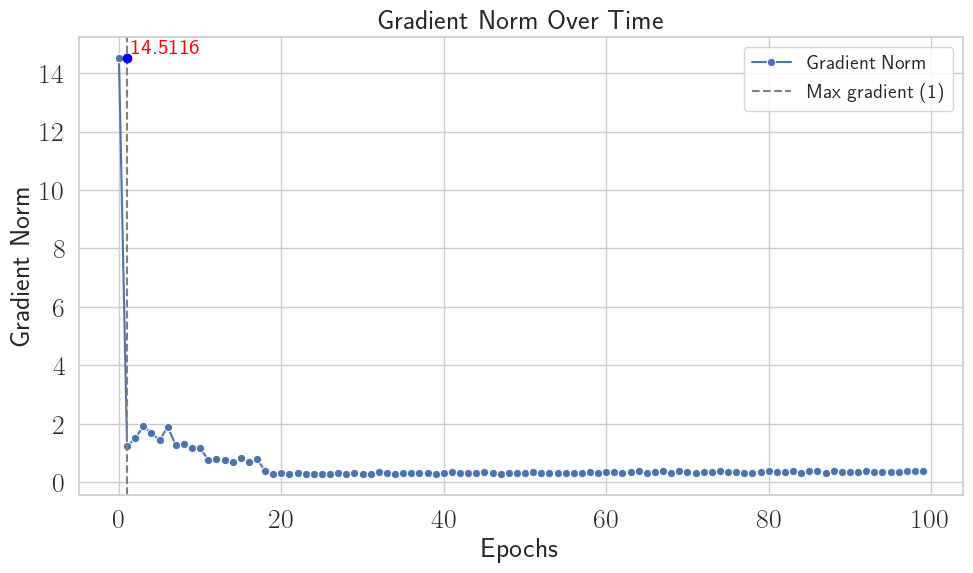

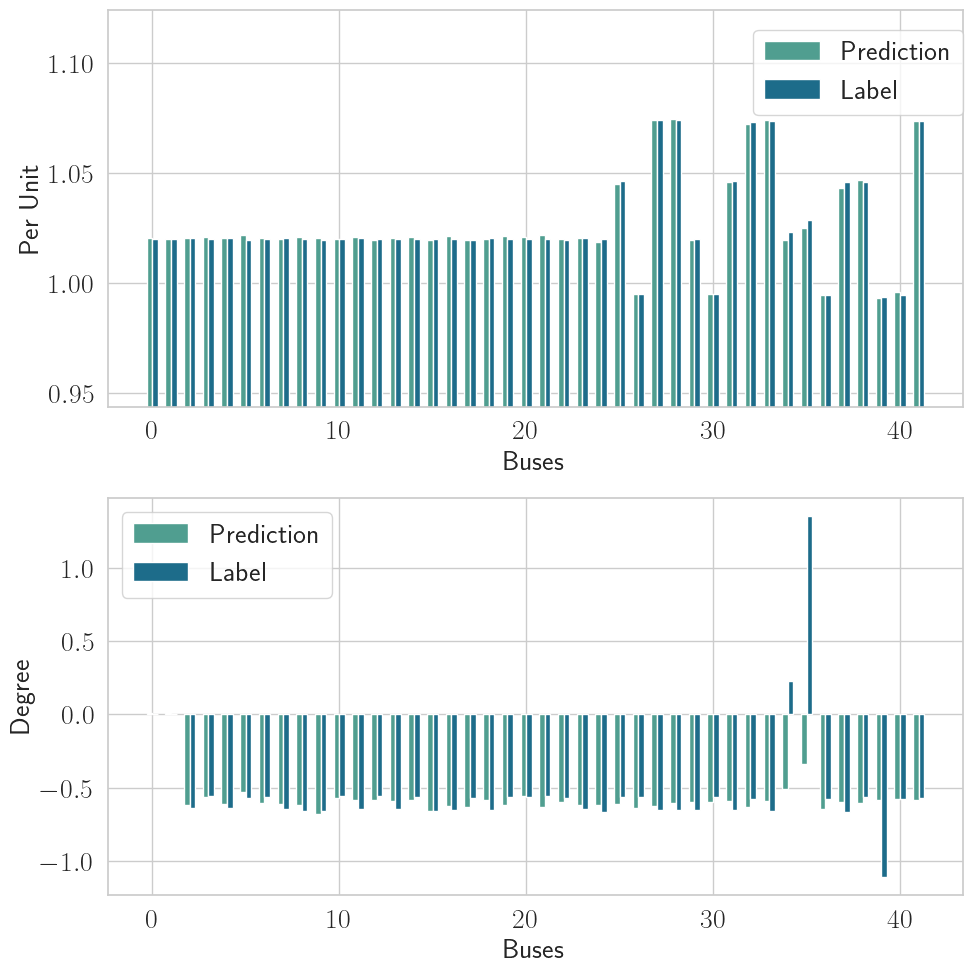

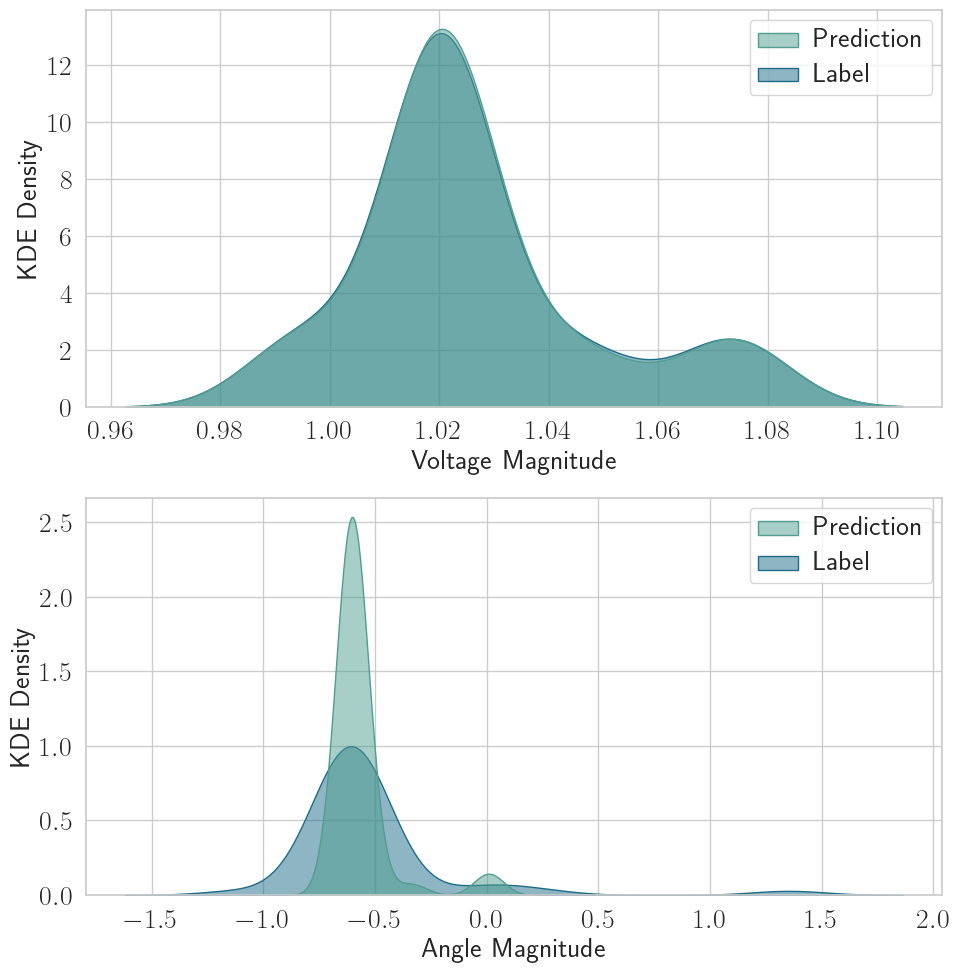

In [8]:
all_loaders, plot_loader = dataset_splitter(dataset,
                                    batch_size=config_tapsegnn['loader']['batch_size'], 
                                    split_list=config_tapsegnn['loader']['split_list'])

model = initialize_model(model_name=config_tapsegnn['model']['name'],
                    dataset=dataset,
                    node_out_features=config_tapsegnn['model']['node_out_features'],
                    list_node_hidden_features=config_tapsegnn['model']['list_node_hidden_features'],
                    k_hop_node=config_tapsegnn['model']['k_hop_node'],
                    edge_out_features=config_tapsegnn['model']['edge_out_features'], 
                    list_edge_hidden_features=config_tapsegnn['model']['list_edge_hidden_features'],
                    k_hop_edge=config_tapsegnn['model']['k_hop_edge'],
                    trafo_hop=config_tapsegnn['model']['trafo_hop'],
                    edge_index_list=sampled_input_data['edge_index'],
                    gat_out_features=config_tapsegnn['model']['gat_out_features'],
                    gat_head=config_tapsegnn['model']['gat_head'],
                    bias=config_tapsegnn['model']['bias'], 
                    normalize=config_tapsegnn['model']['normalize'], 
                    device=device,
                    ).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total number of parameters of model {model}: {total_params}')

optimizer = torch.optim.Adam(model.parameters(),
                             lr=config_tapsegnn['training']['lr'], 
                             weight_decay=config_tapsegnn['training']['weight_decay'])
        
schedular = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer, 
                                                    mode='min',
                                                    factor=0.1, 
                                                    patience=1,
                                                    min_lr=config_tapsegnn['training']['schedular_min_lr'])

all_losses = trainer(model=model, 
                    train_loader=all_loaders[0], 
                    val_loader=all_loaders[1], 
                    test_loader=all_loaders[2], 
                    optimizer=optimizer,
                    schedular=schedular,
                    num_epoch=config_tapsegnn['training']['num_epochs'],
                    early_stopping=config_tapsegnn['training']['early_stopping'],
                    val_patience=config_tapsegnn['training']['val_patience'], 
                    tap_weight=config_tapsegnn['training']['loss_tap_weight'], 
                    device=device)

results = get_eval_results(test_loader=all_loaders[2],
                                tap_weight=config_tapsegnn['training']['loss_tap_weight'], 
                            trained_model=model, 
                            scaler=sampled_input_data['scaler_y_label'])

current_time = datetime.now().strftime("%Y%m%d_%H%M%S")

generate_markdown_report(current_time=current_time,
                        all_losses=all_losses, 
                        config=config_tapsegnn, 
                        results=results, 
                        plot_loader=plot_loader, 
                        trained_model=model, 
                        sampled_input_data=sampled_input_data)
